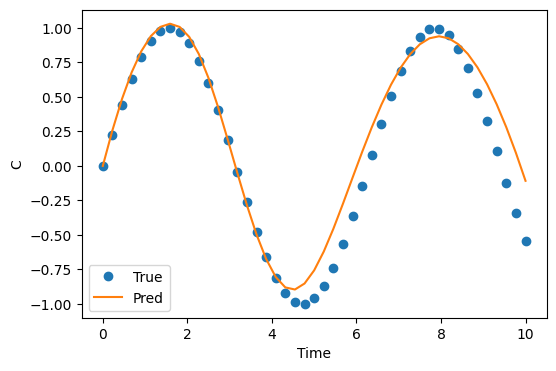

Epoch 1150, Loss: 0.029122
torch.Size([45]) torch.Size([45, 1])
torch.Size([1, 1])


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchdiffeq import odeint
from IPython.display import clear_output
import matplotlib.pyplot as plt

# --- 1. Define MLP ODE function ---
class MLPODEF(nn.Module):
    def __init__(self, hidden_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x, t):
        if x.dim() == 0:
            x = x.unsqueeze(0).unsqueeze(0)
        elif x.dim() == 1:
            x = x.unsqueeze(0)
        return self.net(x)


# --- 2. Define Neural ODE wrapper ---
class NeuralODE(nn.Module):
    def __init__(self, func):
        super().__init__()
        self.func = func

    def forward(self, z0, t, return_whole_sequence=False):
        # odeint expects [batch, state_dim] for z0
        z = odeint(self.func, z0, t)  # output: [time, batch, state_dim]
        if return_whole_sequence:
            return z
        else:
            return z[-1]

# --- 3. Plotting function ---
def plot_results(t, C, traj, save=None):
    plt.figure(figsize=(6,4))
    plt.plot(t, C, 'o', label='True')
    plt.plot(t, traj[:,0,0].detach().numpy(), '-', label='Pred')
    plt.legend()
    plt.xlabel('Time')
    plt.ylabel('C')
    if save:
        plt.savefig(save)
    plt.show()

# --- 4. Training loop ---
def train_model(t, C, ode_trained, epochs=500, lr=0.01, plot_freq=50):
    # Initial state [batch, state_dim]
    z0 = C[0].unsqueeze(0)  # [1,1]
    print(t.shape, C.shape)
    print(z0.shape)

    optimizer = torch.optim.Adam(ode_trained.parameters(), lr=lr)

    for i in range(epochs):
        optimizer.zero_grad()
        z_pred = ode_trained(z0, t, return_whole_sequence=True)  # [time, batch, state_dim]
        loss = F.mse_loss(z_pred[:,0,0], C[:,0])
        loss.backward()
        optimizer.step()

        if i % plot_freq == 0:
            clear_output(wait=True)
            plot_results(t, C, z_pred, save=None)
            print(f'Epoch {i}, Loss: {loss.item():.6f}')
            print(t.shape, C.shape)
            print(z0.shape)

# --- 5. Example usage ---
# Suppose your data:
# C: torch.Size([45,1])
# t: torch.Size([45])
# Just make some dummy example if needed
t = torch.linspace(0, 10, 45)
C = torch.sin(t).unsqueeze(1)  # example data [45,1]
print(t.shape, C.shape)


print("________________")

# Initialize and train
ode_trained = NeuralODE(MLPODEF())
train_model(t, C, ode_trained, epochs=1200, lr=0.05, plot_freq=50)
